# Pipeline — Análisis de Conectividad Cerebral (fMRI)

Pipeline ordenado para análisis de conectividad funcional sobre datos ABIDE.  
Cada módulo vive en su propio `.py`; acá solo se llaman las funciones.

**Archivos requeridos en la misma carpeta:**
- `filtrado.py`
- `parcelacion.py`
- `conectividad.py`
- `visor.py`


## 0. Imports y configuración

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets
import sys
sys.path.append("./script")

# Módulos del pipeline
from script.filtrado import bandpass_filter, filtrar_rois
from script.parcelacion import cargar_atlas, extraer_senales_roi, precalcular_cache_roi
from script.conectividad import correlacion, graphical_lasso, comparar_matrices
from script.visor import visor_cortes, visor_senal_voxel, visor_parcelacion, visor_conectividad

## 1. Cargar datos

Se descarga 1 sujeto del dataset ABIDE (pre-procesado con cpac).  
No descargues todos — son ~70–90 GB. El flujo es: descargar → procesar → borrar, guardar solo el resultado.


In [2]:
abide = datasets.fetch_abide_pcp(
    data_dir='./data',
    n_subjects=1,
    pipeline='cpac',
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=['func_preproc']
)

fmri_img  = nib.load(abide.func_preproc[0])
fmri_data = fmri_img.get_fdata()
TR        = float(fmri_img.header.get_zooms()[3])

x_dim, y_dim, z_dim, t_dim = fmri_data.shape

print(f'Archivo : {abide.func_preproc[0]}')
print(f'Shape   : {fmri_data.shape}  (X, Y, Z, T)')
print(f'TR      : {TR} segundos')

Archivo : ./data\ABIDE_pcp\cpac\nofilt_noglobal\Pitt_0050003_func_preproc.nii.gz
Shape   : (61, 73, 61, 196)  (X, Y, Z, T)
TR      : 1.5 segundos


## 2. Exploración visual

Navegación de cortes axiales con slider de z y timepoint.


In [3]:
visor_cortes(fmri_data)

interactive(children=(IntSlider(value=30, description='z', max=60), IntSlider(value=0, description='t', max=19…

## 3. Señal temporal por voxel

Clic en cualquier voxel del corte axial → muestra la señal original y filtrada (0.01–0.1 Hz).


In [4]:
visor_senal_voxel(fmri_data, bandpass_filter, TR)

interactive(children=(IntSlider(value=30, description='z', max=60), Output()), _dom_classes=('widget-interact'…

## 4. Atlas y parcelación

Se usa el atlas Harvard-Oxford (cort-maxprob-thr25-2mm).  
El atlas se remuestrea al espacio del fMRI y se extrae la señal promedio de cada ROI.  
Solo se incluyen ROIs con al menos 100 voxeles.


In [5]:
atlas_data, atlas_obj = cargar_atlas(fmri_img)

Atlas cargado. Shape: (61, 73, 61) | Regiones: 49


In [6]:
roi_signals, selected_rois, roi_names, roi_sizes = extraer_senales_roi(
    fmri_data, atlas_data, atlas_obj, min_voxels=100
)

print(f'Señales ROI shape: {roi_signals.shape}  (T x n_rois)')

ROIs extraídas: 47 (de 48 totales, mín. 100 voxeles)
Shape señales: (196, 47)
Señales ROI shape: (196, 47)  (T x n_rois)


In [7]:
# Pre-calcular señales orig + filtrada por ROI (necesario para los visores)
roi_signal_cache, roi_name_map, roi_sizes_all = precalcular_cache_roi(
    fmri_data, atlas_data, atlas_obj, bandpass_filter, TR, min_voxels=100
)

Pre-calculando señales ROI (puede tardar ~30s)...
Listo. 47 ROIs con señal precalculada.


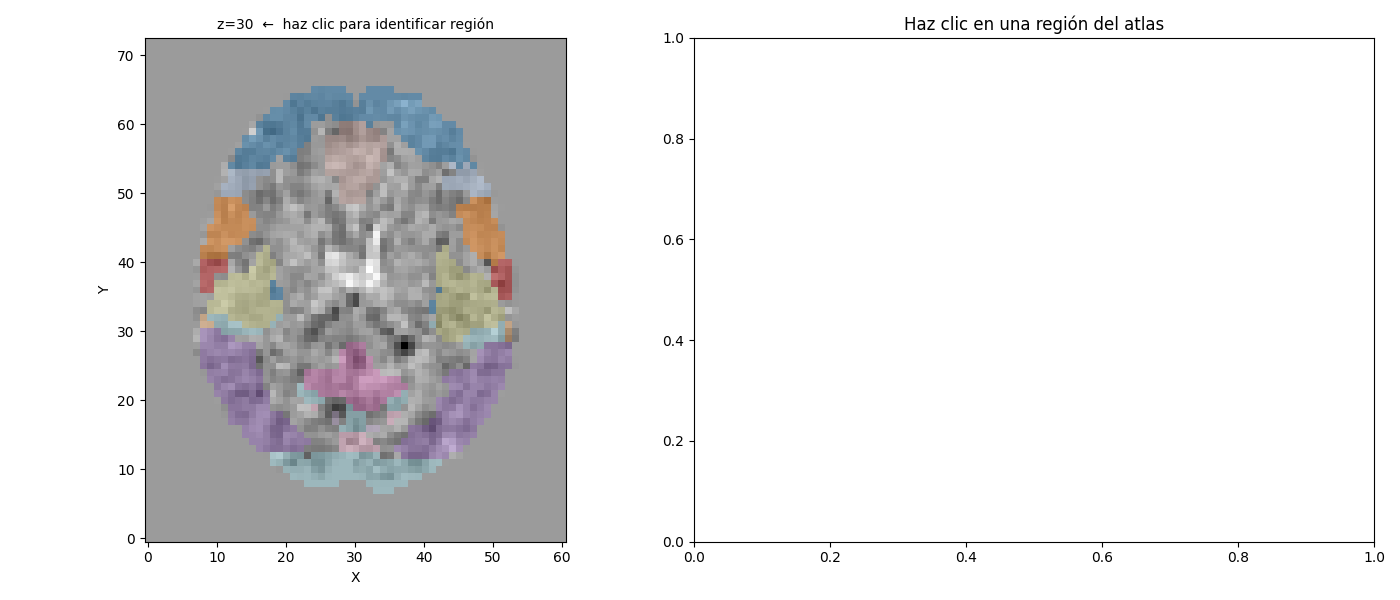

In [8]:
# Visor interactivo: clic en una región → nombre + señal
roi_ids_all = [int(i) for i in np.unique(atlas_data) if i != 0]
visor_parcelacion(fmri_data, atlas_data, roi_signal_cache,
                  roi_name_map, roi_ids_all, roi_sizes_all)

## 5. Filtrado de señales ROI

Filtro pasa-banda Butterworth de orden 4 (0.01–0.1 Hz), estándar en fMRI resting-state.  
Se aplica a todas las ROIs antes de calcular conectividad.


Shape señales filtradas: (196, 47)


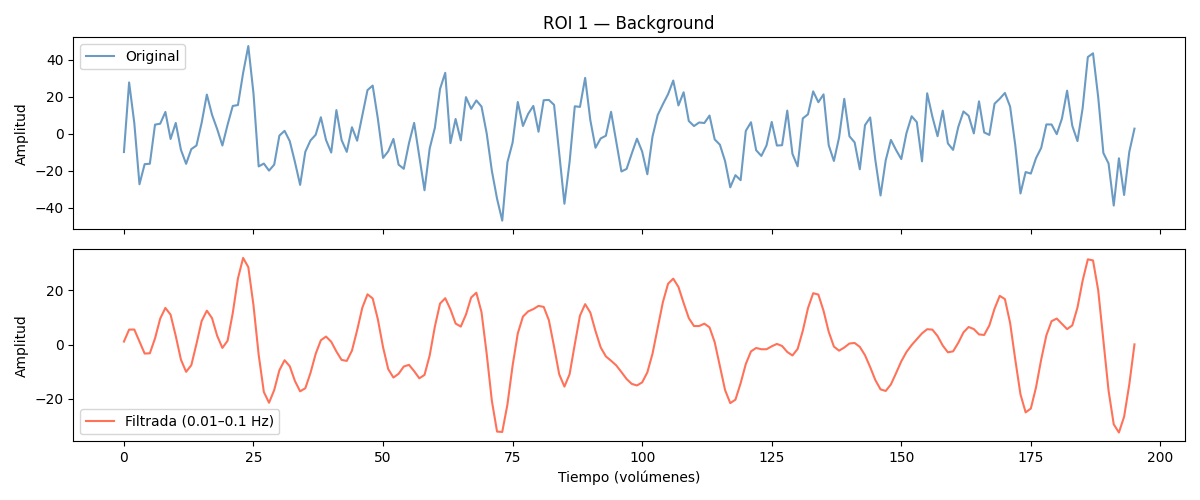

In [9]:
roi_signals_filt = filtrar_rois(roi_signals, TR)

print(f'Shape señales filtradas: {roi_signals_filt.shape}')

# Comparación visual: primera ROI
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(roi_signals[:, 0], color='steelblue', alpha=0.8, label='Original')
axes[0].set_title(f'ROI {selected_rois[0]} — {roi_names[0]}')
axes[0].set_ylabel('Amplitud')
axes[0].legend()
axes[1].plot(roi_signals_filt[:, 0], color='tomato', alpha=0.9, label='Filtrada (0.01–0.1 Hz)')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo (volúmenes)')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Conectividad funcional

Se calculan dos matrices de conectividad sobre las señales **filtradas**:

- **Correlación de Pearson**: mide similitud lineal entre señales ROI.
- **Graphical Lasso**: covarianza inversa sparse. Mide conectividad *condicional* 
  (descarta el efecto de las demás ROIs). Es uno de los métodos implementados en Nilearn.


In [10]:
corr_matrix = correlacion(roi_signals_filt)
print('Correlación — shape:', corr_matrix.shape)

Correlación — shape: (47, 47)


In [11]:
gl_matrix = graphical_lasso(roi_signals_filt)
print('Graphical Lasso — shape:', gl_matrix.shape)

Graphical Lasso — shape: (47, 47)


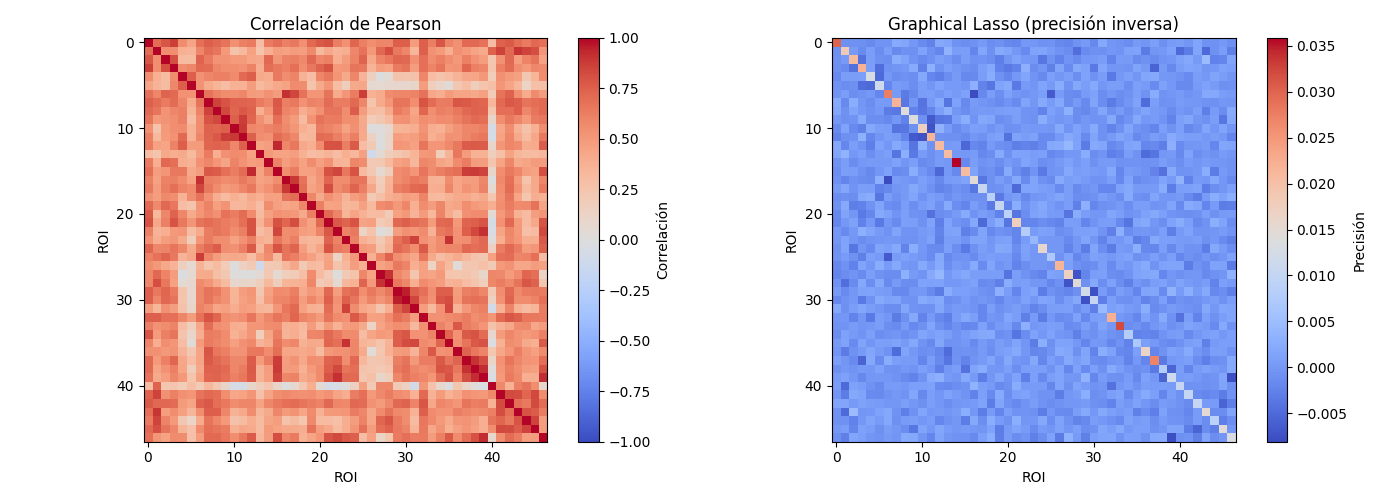

In [12]:
# Visualizar ambas matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title('Correlación de Pearson')
axes[0].set_xlabel('ROI'); axes[0].set_ylabel('ROI')
fig.colorbar(im0, ax=axes[0], label='Correlación')

im1 = axes[1].imshow(gl_matrix, cmap='coolwarm')
axes[1].set_title('Graphical Lasso (precisión inversa)')
axes[1].set_xlabel('ROI'); axes[1].set_ylabel('ROI')
fig.colorbar(im1, ax=axes[1], label='Precisión')

plt.tight_layout()
plt.show()

In [13]:
# Resumen comparativo
comparar_matrices(corr_matrix, gl_matrix, selected_rois, roi_names)

=== Correlación ===
  Media  : 0.5171
  Std    : 0.1868
  Min/Max: -0.0954 / 0.9502

=== Graphical Lasso ===
  Media  : -0.0003
  Std    : 0.0016
  Min/Max: -0.0081 / 0.0048
  Entradas no nulas (triangular sup): 1081 de 1081


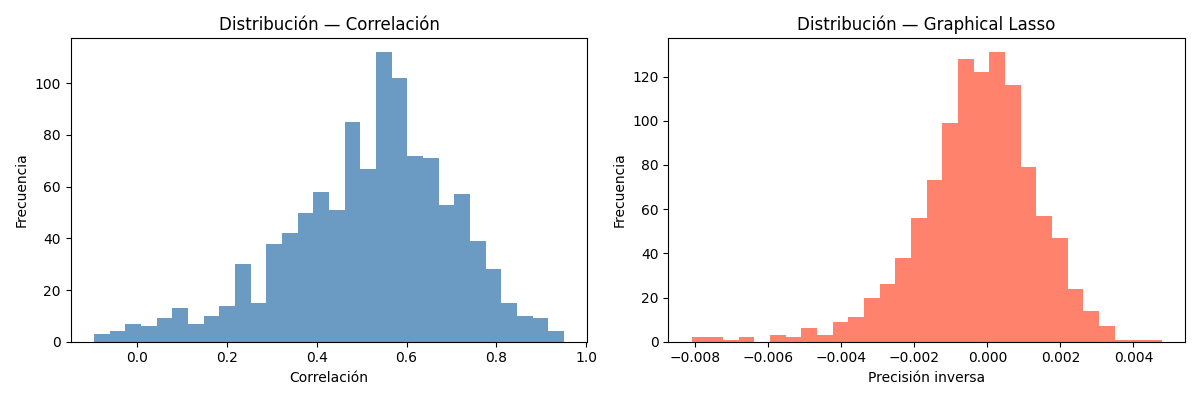

In [14]:
# Distribución de valores (triangular superior)
n = len(selected_rois)
upper = np.triu_indices(n, k=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(corr_matrix[upper], bins=30, color='steelblue', alpha=0.8)
axes[0].set_title('Distribución — Correlación')
axes[0].set_xlabel('Correlación'); axes[0].set_ylabel('Frecuencia')

axes[1].hist(gl_matrix[upper], bins=30, color='tomato', alpha=0.8)
axes[1].set_title('Distribución — Graphical Lasso')
axes[1].set_xlabel('Precisión inversa'); axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 7. Visor de conectividad por ROI

Clic en una región del atlas → calcula el mapa de correlación 3D usando esa ROI como semilla.  
Útil para explorar visualmente qué zonas del cerebro están conectadas con cada región.


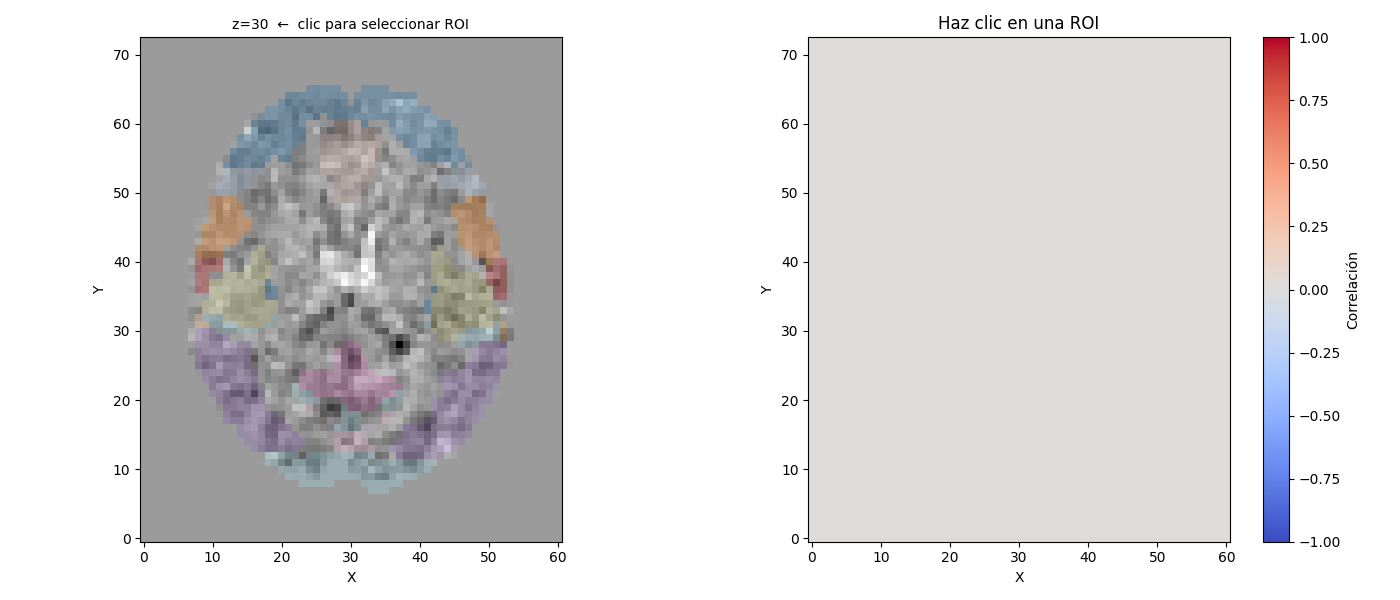

In [15]:
visor_conectividad(fmri_data, atlas_data, roi_signal_cache,
                   roi_name_map, roi_ids_all)

## 8. Guardar resultados

Se guardan las matrices y señales para no tener que re-calcular.  
El sujeto descargado puede borrarse después de este paso.


In [16]:
import os
os.makedirs('resultados', exist_ok=True)

np.save('resultados/roi_signals_orig.npy', roi_signals)
np.save('resultados/roi_signals_filt.npy', roi_signals_filt)
np.save('resultados/corr_matrix.npy',      corr_matrix)
np.save('resultados/gl_matrix.npy',        gl_matrix)
np.save('resultados/selected_rois.npy',    np.array(selected_rois))
np.save('resultados/roi_names.npy',        np.array(roi_names))

print('Guardado en resultados/:')
print('  roi_signals_orig.npy  — señales crudas    (T x ROI)')
print('  roi_signals_filt.npy  — señales filtradas  (T x ROI)')
print('  corr_matrix.npy       — correlación        (ROI x ROI)')
print('  gl_matrix.npy         — graphical lasso    (ROI x ROI)')
print('  selected_rois.npy     — IDs de ROIs usadas')
print('  roi_names.npy         — nombres de ROIs')

Guardado en resultados/:
  roi_signals_orig.npy  — señales crudas    (T x ROI)
  roi_signals_filt.npy  — señales filtradas  (T x ROI)
  corr_matrix.npy       — correlación        (ROI x ROI)
  gl_matrix.npy         — graphical lasso    (ROI x ROI)
  selected_rois.npy     — IDs de ROIs usadas
  roi_names.npy         — nombres de ROIs
